In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import logsumexp
import pickle
import json
from plotting_functions import plot_method_comparison, plot_gillespie_nmc_comparison
from saving_experiments import save_samples, save_samples_summary, load_samples
import os

# Generating Data and storing class

## Data Sampling Functions

In [ ]:
def sample_from_pi(w, mu, rng=None):
    """
    Sample x from the true mixture q(x) = sum_i w_i ∏_j mu[i,j,x_j].
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component-wise categorical probabilities
    rng : np.random.Generator, optional
        Random number generator
    
    Returns
    -------
    x : np.ndarray, shape (N,)
        Sample from the mixture
    """
    if rng is None:
        rng = np.random.default_rng()
    w = np.asarray(w)
    mu = np.asarray(mu)
    r, N, L = mu.shape
    
    # Pick mixture component
    i = rng.choice(r, p=w)
    
    # Sample each coordinate independently from that component
    # x = np.empty(N, dtype=int)
    # for j in range(N):
    #     x[j] = rng.choice(L, p=mu[i, j])

    # More efficient
    cdf = np.cumsum(mu[i], axis=1)
    u = rng.random((N, 1))
    x = (cdf < u).sum(axis=1)
    
    return x


def make_conditional_prob_fn_mixture(w, mu, MASK=-1, eps=1e-300):
    """
    Build conditional probability function for the mixture-of-independent-coordinates model.
    
    Data model:
        p_data(x) = sum_r w[r] * prod_j mu[r, j, x_j]
    
    For a partially masked vector z, this returns
        probs[j, v] = p_data(X_j = v | X_i = z_i for all visible i)
    where visible means z[i] != MASK.
    
    Parameters
    ----------
    w : np.ndarray, shape (R,)
        Mixture weights
    mu : np.ndarray, shape (R, N, L)
        Component-wise categorical probabilities
        mu[r, j, v] = p(X_j = v | component r)
    MASK : int
        Mask token
    eps : float
        Numerical stability constant
    
    Returns
    -------
    cond_prob_fn : callable
        cond_prob_fn(z) returns an array of shape (N, L)
    """
    w = np.asarray(w, dtype=float)
    mu = np.asarray(mu, dtype=float)
    
    if w.ndim != 1:
        raise ValueError("w must have shape (R,)")
    if mu.ndim != 3:
        raise ValueError("mu must have shape (R, N, L)")
    
    R, N, L = mu.shape
    if w.shape[0] != R:
        raise ValueError("w and mu have inconsistent number of mixture components")
    
    # Normalize mixture weights
    w = np.clip(w, 0.0, None)
    w_sum = w.sum()
    if w_sum <= 0:
        raise ValueError("mixture weights must have positive sum")
    w = w / w_sum
    
    # Normalize mu
    mu = np.clip(mu, 0.0, None)
    mu_sum = mu.sum(axis=-1, keepdims=True)
    mu = np.divide(mu, mu_sum, out=np.ones_like(mu) / L, where=(mu_sum > 0))
    
    log_w = np.log(np.clip(w, eps, None))
    log_mu = np.log(np.clip(mu, eps, None))
    
    def logsumexp_stable(a):
        a = np.asarray(a, dtype=float)
        a_max = np.max(a)
        if not np.isfinite(a_max):
            return -np.inf
        return a_max + np.log(np.sum(np.exp(a - a_max)))
    
    def cond_prob_fn(z):
        z = np.asarray(z, dtype=int)
        if z.shape != (N,):
            raise ValueError(f"z must have shape ({N},), got {z.shape}")
        
        visible_idx = np.where(z != MASK)[0]
        
        # Log posterior over mixture components:
        # log p(r | visible z) ∝ log w_r + sum_{i visible} log mu[r, i, z_i]
        log_comp = log_w.copy()
        # for i in visible_idx:
        #     v = int(z[i])
        #     if v < 0 or v >= L:
        #         raise ValueError(f"visible token z[{i}]={v} is outside [0, {L-1}]")
        #     log_comp += log_mu[:, i, v]

        # More efficient
        if len(visible_idx) > 0:
            v = z[visible_idx].astype(int)
            if np.any((v < 0) | (v >= L)):
                raise ValueError(f"visible token z[{visible_idx[0]}]={v[0]} is outside [0, {L-1}]")
            log_comp += log_mu[:, visible_idx, v].sum(axis=1)
        
        log_Z = logsumexp_stable(log_comp)
        if not np.isfinite(log_Z):
            comp_post = np.ones(R, dtype=float) / R
        else:
            comp_post = np.exp(log_comp - log_Z)
            comp_post = comp_post / comp_post.sum()
        
        # Predictive distribution:
        # p(X_j = v | visible z) = sum_r p(r | visible z) mu[r, j, v]
        probs = np.einsum("r,rjl->jl", comp_post, mu)
        
        # Normalize rows
        probs = np.clip(probs, 0.0, None)
        row_sums = probs.sum(axis=1, keepdims=True)
        probs = np.divide(probs, row_sums, out=np.ones_like(probs) / L, where=(row_sums > 0))
        
        return probs
    
    return cond_prob_fn


In [ ]:
def _update_omega(omega, mu, block, x_vals, w=None, recompute=False):
    """
    Bayesian reweighting of the mixture posterior after revealing x_vals.
    
    Two modes:
    - recompute=False (default): incremental update, multiplies current omega
      by the likelihood of the newly revealed tokens in block:
        omega_i <- omega_i * prod_{j in block} mu_{i,j}(x_j)  (normalised)
    - recompute=True: recomputes omega from scratch starting from prior w,
      using all coordinates in block. Used after corrector steps where some
      tokens may have been re-masked and omega needs to be resynced.
        omega_i <- w_i * prod_{j in block} mu_{i,j}(x_j)  (normalised)
    
    Parameters
    ----------
    omega : np.ndarray, shape (r,)
        Current mixture posterior.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals.
    block : list of int
        Coordinate indices to condition on.
    x_vals : np.ndarray, shape (N,)
        Current sequence state, used to look up x_vals[j] for j in block.
    w : np.ndarray, shape (r,), optional
        Prior mixture weights. Required if recompute=True.
    recompute : bool
        If True, recompute omega from scratch using prior w.
        If False, incrementally update current omega.
    
    Returns
    -------
    omega : np.ndarray, shape (r,)
        Updated (or recomputed) posterior weights.
    """
    if recompute:
        assert w is not None, "w must be provided when recompute=True"
        log_w = np.log(np.clip(w, 1e-300, None))
    else:
        log_w = np.log(np.clip(omega, 1e-300, None))
    
    for j in block:
        log_w += np.log(np.clip(mu[:, j, x_vals[j]], 1e-300, None))
    
    log_w -= logsumexp(log_w)
    return np.exp(log_w)

In [ ]:
def force_unmask_remaining_tokens(
    x_final,
    unmasking_prob_fn,
    MASK=-1,
    rng=None,
    sample=True,
):
    """
    Force all remaining MASK entries in a single sample to become visible.

    Parameters
    ----------
    x_final : np.ndarray, shape (N,)
        Final sample containing states and possibly MASK.
    unmasking_prob_fn : callable # produced by make_conditional_prob_fn_mixture
        Function taking a partially masked sample and returning per-position
        categorical probabilities over visible states.
        Expected shape: (N, r) if there are r visible states.
    MASK : int
        Mask token.
    rng : np.random.Generator or None
        RNG for sampling.
    sample : bool
        If True, sample from predicted probabilities.
        If False, use argmax.

    Returns
    -------
    x_out : np.ndarray
        Same shape as x_final, with no MASK tokens left.
    """
    if rng is None:
        rng = np.random.default_rng()

    x_out = x_final.copy()
    masked_idx = np.where(x_out == MASK)[0]

    if len(masked_idx) == 0:
        return x_out

    probs = unmasking_prob_fn(x_out)   # expected shape (N, r)

    for j in masked_idx:
        p = probs[j].astype(float)
        p = np.clip(p, 0.0, None)
        s = p.sum()
        if s <= 0:
            # fallback to uniform if something degenerate happens
            p = np.ones_like(p) / len(p)
        else:
            p = p / s

        if sample:
            x_out[j] = rng.choice(len(p), p=p)
        else:
            x_out[j] = np.argmax(p)

    return x_out



## Forward Process Simulation

In [ ]:
def generate_forward_samples_at_checkpoints(w, mu, beta, checkpoint_times, n_mc, MASK=-1):
    """
    Generate forward samples at checkpoint times using marginal distributions.
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component probabilities
    beta : float
        Masking rate
    checkpoint_times : array-like
        Physical times in [0, T] at which to sample
    n_mc : int
        Number of samples
    MASK : int
        Mask token
    
    Returns
    -------
    forward_samples : dict[float, np.ndarray]
        forward_samples[t] = array of shape (n_mc, N) at time t
    """
    N = mu.shape[1]
    checkpoint_times = np.sort(np.unique(checkpoint_times))
    forward_samples = {}
    rng = np.random.default_rng()
    
    for m in range(n_mc):
        # if m % 100 == 0:
        #     print(f"  Forward particle {m}/{n_mc}")
        
        # Sample clean data at t=0
        x0 = sample_from_pi(w, mu, rng=np.random.default_rng(rng.integers(1_000_000_000)))
        
        # Generate samples at each checkpoint time
        for t in checkpoint_times:
            if m == 0:
                forward_samples[float(t)] = np.empty((n_mc, N), dtype=np.int16)
            
            if t == 0.0:
                # At t=0, use clean data
                forward_samples[float(t)][m] = x0
            else:
                # At t>0, apply forward marginal from t=0
                x_t = forward_marginal(
                    x0, beta, t, 
                    rng=np.random.default_rng(rng.integers(1_000_000_000))
                )
                forward_samples[float(t)][m] = x_t
    
    return forward_samples


def forward_marginal(x_t, beta, delta_t, rng=None, MASK=-1):
    """
    Corrupt x_t to time t + delta_t using the forward masking process.
    Each UNMASKED coordinate j is masked independently with probability 1 - e^{-beta*(delta_t)}.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    alpha_dt = np.exp(-beta * delta_t)
    x_t_delta_t = x_t.copy()
    
    # Only mask currently UNMASKED tokens
    unmasked_mask = (x_t != MASK)
    new_mask = rng.random(len(x_t)) < (1 - alpha_dt)
    
    # Apply masking only to unmasked positions
    x_t_delta_t[unmasked_mask & new_mask] = MASK
    
    return x_t_delta_t


Storiing the forward process particles

In [ ]:
def run_diffusion_experiment(w, mu, beta, T, n_mc, checkpoint_times):
    """
    Run forward process once, then can run multiple reverse methods.
    """
    N = mu.shape[1]
    checkpoint_times = np.sort(np.unique(checkpoint_times))
    
    samples = DiffusionSamples(checkpoint_times, n_mc, N)
    
    print("Running forward process...")
    samples.forward = generate_forward_samples_at_checkpoints(
        w, mu, beta, checkpoint_times, n_mc
    )
    
    return samples

## Reverse Process Simulation (Gillespie)

In [ ]:
def gillespie_reverse_masked(
    N, w, mu, beta, T=1.0, MASK=-1, rng=None,
    checkpoint_times=None, unmasking_prob_fn=None
):
    """
    Exact Gillespie reverse sampler for constant-rate masked diffusion.
    """
    if rng is None:
        rng = np.random.default_rng()
    if unmasking_prob_fn is None:
        unmasking_prob_fn = make_conditional_prob_fn_mixture(w, mu, MASK=MASK)
    
    # Normalize checkpoint times
    checkpoint_times = np.sort(np.unique(np.asarray(checkpoint_times, dtype=float)))
    
    # Storage: ARRAY not dict!
    checkpoint_samples = np.empty((len(checkpoint_times), N), dtype=int)
    
    # Initialize pointer for checkpoint times
    ckpt_ptr = len(checkpoint_times) - 1
    
    # Start at t=T (fully masked)
    x = np.full(N, MASK, dtype=int)
    t = float(T)
    
    # Record initial state at all checkpoints >= T
    while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] >= t:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Simulate backward from T to 0
    while t > 0 and np.any(x == MASK):
        masked_idx = np.where(x == MASK)[0]
        M = len(masked_idx)
        x_before_jump = x.copy()

        alpha_t = np.exp(-beta * t)
        E = rng.exponential(1.0)
        one_minus_alpha_s = (1.0 - alpha_t) * np.exp(-E / M)

        alpha_s = 1.0 - one_minus_alpha_s
        alpha_s = np.clip(alpha_s, 0.0, 1.0)

        if alpha_s >= 1.0:
            s = 0.0
        else:
            s = -np.log(alpha_s) / beta
            s = max(s, 0.0)

        # Record checkpoints BEFORE applying the jump
        while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] > s:
            checkpoint_samples[ckpt_ptr] = x_before_jump.copy()
            ckpt_ptr -= 1

        # Now move to event time and apply jump
        t = s

        d = rng.choice(masked_idx)
        probs = unmasking_prob_fn(x)[d].astype(float)
        probs = np.clip(probs, 0.0, None)
        probs = probs / probs.sum()
        x[d] = rng.choice(len(probs), p=probs)
        

    
    # Fill any remaining checkpoints with final state
    while ckpt_ptr >= 0:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Return array, not dict!
    return x, checkpoint_times, checkpoint_samples

### Adding particles to Container

In [ ]:
def add_gillespie_reverse(samples, w, mu, beta, T):
    """
    Add Gillespie reverse samples to existing DiffusionSamples.
    """

    n_mc = samples.metadata['n_mc']
    N = samples.metadata['N']
    checkpoint_times = samples.times
    method_name = f"gillespie"
    samples.reverse_methods[method_name] = {}
    for t in checkpoint_times:
        samples.reverse_methods[method_name][float(t)] = np.empty((n_mc, N), dtype=np.int16)
    
    print("Running Gillespie reverse process...")
    rng = np.random.default_rng()
    for m in range(n_mc):
        if m % 10000 == 0:
            print(f"  Gillespie particle {m}/{n_mc}")
        
        final_state, times, ckpt_samples = gillespie_reverse_masked(
            N, w, mu, beta, T,
            checkpoint_times=checkpoint_times,
            rng=np.random.default_rng(rng.integers(1_000_000_000))
        )
        
        for k, t in enumerate(times):
            samples.reverse_methods["gillespie"][float(t)][m] = ckpt_samples[k]

## Reverse Process Simulation (Tau-Leaping)

In [ ]:
def tau_leap_step(x_t, w, mu, beta, t, tau, MASK=-1, rng=None, return_rates=False, force_unmask_K=0):
    """
    One reverse tau-leap step for masked diffusion using the 'keep last event'
    rule per coordinate.

    Assumptions
    -----------
    - Coordinates are conditionally independent within the leap once rates are fixed.
    - Unmasked coordinates stay unchanged in the reverse process.
    - For a masked coordinate d, reverse rates are
          lambda_{d,j} = c(t) * q(x0^d = j | x_t)
      with
          c(t) = beta * alpha_t / (1 - alpha_t),
          alpha_t = exp(-beta * t).

    Parameters
    ----------
    x_t : (N,) int array
        Current partially masked state.
    w   : (r,) array
        Mixture weights.
    mu  : (r, N, L) array
        Mixture component marginals.
    beta : float
        Constant masking rate.
    t : float
        Current time.
    tau : float
        Leap size.
    MASK : int
        Sentinel value used for masked coordinates.
    rng : np.random.Generator or None
    return_rates : bool
        If True, also return omega, lambda_mat, Lambda_vec.
    force_unmask_K : int
        If > 0, force this many additional tokens to unmask by selecting
        those with highest u values among tokens that would stay masked.
        Used for PRISM corrector compensation.

    Returns
    -------
    x_next : (N,) int array
        State after one approximate reverse tau-leap.
    optionally:
    omega      : (r,) posterior component weights
    lambda_mat : (N, L) rates lambda_{d,j} (zeros for unmasked coords)
    Lambda_vec : (N,) total rates per coordinate
    """
    if rng is None:
        rng = np.random.default_rng()

    x_t = np.asarray(x_t, dtype=int)
    w = np.asarray(w, dtype=float)
    mu = np.asarray(mu, dtype=float)

    r, N, L = mu.shape
    assert x_t.shape == (N,)

    alpha_t = np.exp(-beta * t)
    denom = max(1.0 - alpha_t, 1e-300)
    c_t = beta * alpha_t / denom

    # unmasked_idx = [j for j in range(len(x_t)) if x_t[j] != MASK]
    # More efficient
    unmasked_idx = np.where(x_t != MASK)[0]
    omega = np.ones(r) / r
    omega = _update_omega(omega, mu, unmasked_idx, x_t, w=w, recompute=True)    

    x_next = x_t.copy()
    lambda_mat = np.zeros((N, L), dtype=float)
    Lambda_vec = np.zeros(N, dtype=float)

    masked_idx = np.where(x_t == MASK)[0]

    # for d in masked_idx:
    #     # q(x0^d = j | x_t)
    #     p_d = omega @ mu[:, d, :] # posterior prob over possible tken values at coordinate d, given the currenlty visible coordinates
    #     p_d = np.clip(p_d, 0.0, None)
    #     p_d_sum = p_d.sum()
    #     if p_d_sum <= 0:
    #         continue
    #     p_d /= p_d_sum

    #     # reverse rates
    #     lam_d = c_t * p_d
    #     Lambda_d = lam_d.sum() # it stores only the possible trnasitionspaces, so not MASK hence we can sumall of them

    #     lambda_mat[d] = lam_d
    #     Lambda_vec[d] = Lambda_d

    #     # keep masked with probability exp(-tau * Lambda_d)
    #     if Lambda_d <= 0:
    #         print("NEGATIVE RATES FOUND")
    #         continue

    #     stay_prob = np.exp(-tau * Lambda_d)
    #     if rng.random() < stay_prob:
    #         x_next[d] = MASK
    #     else:
    #         x_next[d] = rng.choice(L, p=lam_d / Lambda_d) #chose the state withprob lam_d/Lam_d

    # if return_rates:
    #     return x_next, omega, lambda_mat, Lambda_vec
    # return x_next

    # More efficient vectorized version
    if masked_idx.size == 0:
        if return_rates:
            return x_next, omega, lambda_mat, Lambda_vec
        return x_next

    # p_all[k, l] = p(x_0^d = l | current visible context)
    # where d = masked_idx[k]
    p_all = np.tensordot(omega, mu[:, masked_idx, :], axes=(0, 0))
    p_all = np.clip(p_all, 0.0, None)

    # Normalize each masked coordinate distribution
    row_sums = p_all.sum(axis=1, keepdims=True)
    valid = row_sums[:, 0] > 0

    p_all[valid] /= row_sums[valid]
    p_all[~valid] = 0.0

    # Reverse rates
    lam_all = c_t * p_all
    Lambda_all = lam_all.sum(axis=1)

    # Invalid rows should have zero total rate
    Lambda_all[~valid] = 0.0

    # Stay masked with probability exp(-tau * Lambda_d)
    stay_prob = np.exp(-tau * Lambda_all)
    
    # Generate random numbers for all masked tokens
    u = rng.random(masked_idx.size)
    stay_mask = u < stay_prob
    
    # ===== PRISM CORRECTION: Force K additional unmaskings =====
    if force_unmask_K > 0:
        # Find indices where tokens would stay masked (stay_mask == True)
        staying_idx = np.where(stay_mask)[0]
        
        if len(staying_idx) > 0:
            # Get u values for those that are staying masked
            u_staying = u[staying_idx]
            
            # How many to force unmask
            K_force = min(force_unmask_K, len(staying_idx))
            
            # Find K_force tokens with HIGHEST u values among stayers
            # (closest to stay_prob threshold, almost unmasked naturally)
            highest_u_indices = staying_idx[np.argsort(u_staying)[-K_force:]]
            
            # Force them to unmask by setting stay_mask to False
            stay_mask[highest_u_indices] = False

    # Unmask selected coordinates (those with stay_mask == False)
    unmask_idx = masked_idx[~stay_mask]

    if unmask_idx.size > 0:
        p_unmask = p_all[~stay_mask]

        # Inverse-CDF categorical sampling
        u_sample = rng.random((unmask_idx.size, 1))
        cdf = np.cumsum(p_unmask, axis=1)

        sampled_values = (cdf < u_sample).sum(axis=1)
        x_next[unmask_idx] = sampled_values

    if return_rates:
        lambda_mat[masked_idx] = lam_all
        Lambda_vec[masked_idx] = Lambda_all
        return x_next, omega, lambda_mat, Lambda_vec

    return x_next

In [ ]:
def tau_leap_reverse_masked(
    N, w, mu, beta, T=1.0, tau=0.01, MASK=-1, rng=None,
    checkpoint_times=None, unmasking_prob_fn=None
):
    """
    Tau-leaping reverse sampler for masked diffusion.
    
    Parameters
    ----------
    N : int
        Number of dimensions
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component probabilities
    beta : float
        Forward masking rate
    T : float
        Terminal time
    tau : float
        Tau-leaping step size
    MASK : int
        Mask token value
    rng : np.random.Generator, optional
        Random number generator
    checkpoint_times : array-like
        Times at which to save state (physical time in [0, T])
    unmasking_prob_fn : callable, optional
        Not used in tau-leaping (uses internal rate computation)
    
    Returns
    -------
    final_state : np.ndarray, shape (N,)
        Final state at t=0
    checkpoint_times : np.ndarray
        Array of checkpoint times
    checkpoint_samples : np.ndarray, shape (n_checkpoints, N)
        States at each checkpoint time
    """
    if rng is None:
        rng = np.random.default_rng()
    
    # Normalize checkpoint times
    checkpoint_times = np.sort(np.unique(np.asarray(checkpoint_times, dtype=float)))
    
    # Storage: ARRAY not dict
    checkpoint_samples = np.empty((len(checkpoint_times), N), dtype=int)
    
    # Initialize pointer
    ckpt_ptr = len(checkpoint_times) - 1
    
    # Start at t=T (fully masked)
    x = np.full(N, MASK, dtype=int)
    t = float(T)
    
    # Record initial state at all checkpoints >= T
    while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] >= t:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Simulate backward from T to 0 using tau-leaping
    while t > tau:  # Stop when we can't take a full tau step
        # Take one tau-leap step backward
        x = tau_leap_step(x, w, mu, beta, t, tau, MASK=MASK, rng=rng)
        
        # Move backward in time
        t = t - tau
        
        # Record checkpoints for all times in (t, t+tau]
        while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] > t:
            checkpoint_samples[ckpt_ptr] = x.copy()
            ckpt_ptr -= 1
    
    # Final step: handle remaining time from t to 0
    if t > 0:
        final_tau = t  # Take a smaller step to exactly reach t=0
        x = tau_leap_step(x, w, mu, beta, t, final_tau, MASK=MASK, rng=rng)
        t = 0.0
    
    # Fill any remaining checkpoints with final state
    while ckpt_ptr >= 0:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Return array, not dict!
    return x, checkpoint_times, checkpoint_samples




### Adding Particles to Container

In [ ]:
# from math import tau


# def add_tau_leap_reverse(samples, w, mu, beta, T, tau, corrector_start=None):
#     """
#     Add tau-leaping reverse samples to existing DiffusionSamples.
    
#     Parameters
#     ----------
#     samples : DiffusionSamples
#         Container with forward samples already computed
#     w : np.ndarray
#         Mixture weights
#     mu : np.ndarray
#         Component probabilities
#     beta : float
#         Masking rate
#     T : float
#         Terminal time
#     tau : float
#         Tau-leaping step size
#     corrector_start : float, optional
#         Time at which to start applying the corrector
#     """
#     n_mc = samples.metadata['n_mc']
#     N = samples.metadata['N']
#     checkpoint_times = samples.times
    
#     # Create method name with tau value
#     method_name = f"tau_leap_{tau}_corrector_start_{corrector_start}"
    
#     # Pre-allocate storage
#     samples.reverse_methods[method_name] = {}
#     for t in checkpoint_times:
#         samples.reverse_methods[method_name][float(t)] = np.empty((n_mc, N), dtype=np.int16)
    
#     print(f"Running tau-leaping (tau={tau}) reverse process...")
#     rng = np.random.default_rng()
    
#     for m in range(n_mc):
#         if m % 10_000 == 0:
#             print(f"  Tau-leap particle {m}/{n_mc}")
        
#         final_state, times, ckpt_samples = tau_leap_reverse_masked(
#             N, w, mu, beta, T, tau=tau,
#             checkpoint_times=checkpoint_times,
#             rng=np.random.default_rng(rng.integers(1_000_000_000))
#         )
        
#         # Direct assignment (fast!)
#         for k, t in enumerate(times):
#             samples.reverse_methods[method_name][float(t)][m] = ckpt_samples[k]


## Reverse Process Simulation (Tau-Leaping + Corrector steps)

### Correctors

In [ ]:
def apply_corrector(
    x, w, mu, beta, t, method, hyperparameters, MASK=-1, rng=None
):
    """
    Apply corrector step based on the specified method.
    
    Parameters
    ----------
    x : np.ndarray, shape (N,)
        Current state
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component probabilities
    beta : float
        Forward masking rate
    t : float
        Current time
    method : str
        Corrector method ('random_masking', 'PRISM', etc.)
    hyperparameters : dict
        Method-specific hyperparameters
    MASK : int
        Mask token value
    rng : np.random.Generator, optional
        Random number generator
    
    Returns
    -------
    x_corrected : np.ndarray, shape (N,)
        State after corrector step(s)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    if method == 'random_masking':
        # Extract hyperparameters
        n_corr = hyperparameters.get('n_corr', 1)
        tau_c = hyperparameters.get('tau_c', 0.01)
        apply_reverse = hyperparameters.get('apply_reverse', True)  # New parameter
        
        # Apply corrector n_corr times
        x_corrected = x.copy()
        for _ in range(n_corr):
            x_corrected = random_masking_corrector_step(
                x_corrected, w, mu, beta, t, tau_c, 
                MASK=MASK, rng=rng, apply_reverse=apply_reverse
            )
        
        return x_corrected
    
    elif method == 'PRISM':
        # Extract PRISM-specific parameters
        K = hyperparameters.get('K', 0)
        old_x = hyperparameters.get('old_x', None)
        unmasking_prob_fn = hyperparameters.get('unmasking_prob_fn', None)
        
        # Early exit if no correction needed
        if K <= 0 or old_x is None or unmasking_prob_fn is None:
            return x
        
        # Apply PRISM corrector: remask K lowest-scoring tokens
        x_corrected, scores, remasked_idx = prism_corrector_step(
            y=x,
            old_y=old_x,
            unmasking_prob_fn=unmasking_prob_fn,
            K=K,
            MASK=MASK,
            rng=rng
        )
        
        return x_corrected
    # In apply_corrector:
    elif method == 'informed_corrector':
        K = hyperparameters.get('K', 1)
        n_corr = hyperparameters.get('n_corr', 8)
        gamma = hyperparameters.get('gamma', 1.0)
        use_margin = hyperparameters.get('use_margin', True)
        unmasking_prob_fn = hyperparameters.get('unmasking_prob_fn')
        
        if unmasking_prob_fn is None:
            return x
        
        x_corrected = informed_corrector_step(
            x,
            unmasking_prob_fn=unmasking_prob_fn,
            K=K,
            n_corr=n_corr,
            gamma=gamma,
            use_margin=use_margin,
            MASK=MASK,
            rng=rng
        )
        
        return x_corrected
    else:
        raise ValueError(f"Unknown corrector method: {method}")

#### Random Masking - Campbell et al.

In [ ]:
def random_masking_corrector_step(x, w, mu, beta, t, tau_c, MASK=-1, rng=None, 
                                  apply_reverse=True):
    """
    Random masking corrector: forward masking optionally followed by reverse tau-leap.
    
    Parameters
    ----------
    x : np.ndarray, shape (N,)
        Current state
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component probabilities
    beta : float
        Forward masking rate
    t : float
        Current time
    tau_c : float
        Corrector step size
    MASK : int
        Mask token value
    rng : np.random.Generator, optional
        Random number generator
    apply_reverse : bool
        If True: forward mask + reverse tau-leap (default)
        If False: forward mask only
    
    Returns
    -------
    x_corrected : np.ndarray, shape (N,)
        State after corrector step
    """
    if rng is None:
        rng = np.random.default_rng()
    
    # Step 1: Forward - randomly mask some unmasked tokens
    x_temp = x.copy()
    unmasked_idx = np.where(x_temp != MASK)[0]
    
    if len(unmasked_idx) == 0:
        return x_temp
    
    # Probability to mask each unmasked token
    p_mask = 1.0 - np.exp(-beta * tau_c)
    to_mask = rng.random(len(unmasked_idx)) < p_mask
    x_temp[unmasked_idx[to_mask]] = MASK
    
    # Step 2 (optional): Backward - apply reverse tau-leap
    if apply_reverse:
        x_corrected = tau_leap_step(x_temp, w, mu, beta, t, tau_c, MASK=MASK, rng=rng)
    else:
        x_corrected = x_temp
    
    return x_corrected

#### PRISM Kim et al.

In [ ]:
# def oracle_scores_for_mixture(
#     y,
#     unmasking_prob_fn,  # This is make_conditional_prob_fn_mixture result
#     MASK=-1,
# ):
#     """
#     Compute oracle self-correction scores for one particle y.
#     For each visible position i, returns
#         g_i(y) = p_data(X_i = y_i | visible context excluding i)
    
#     Parameters
#     ----------
#     y : np.ndarray, shape (N,)
#         One particle / sequence. Masked positions are equal to MASK.
#     unmasking_prob_fn : callable
#         Function from make_conditional_prob_fn_mixture that takes a state
#         and returns p(X_j = v | visible tokens) for all j, v
#         Returns array of shape (N, L)
#     MASK : int, default=-1
#         Mask token.
    
#     Returns
#     -------
#     scores : np.ndarray, shape (N,)
#         scores[i] = oracle score if y[i] is visible, np.nan if y[i] is masked.
#     """
#     y = np.asarray(y)
#     N = len(y)
#     scores = np.full(N, np.nan, dtype=float)
#     visible_idx = np.where(y != MASK)[0]
    
#     for i in visible_idx:
#         # Build context excluding position i (mask it out)
#         context = y.copy()
#         context[i] = MASK
        
#         # Get conditional probabilities at position i given other visible tokens
#         # Shape: (N, L) where L is vocab size
#         probs = unmasking_prob_fn(context)
        
#         # Extract probability for the actual value y[i] at position i
#         # probs[i] is the distribution over vocab at position i
#         # y[i] is the actual value, so probs[i, y[i]] is p(X_i = y[i] | context)
#         scores[i] = probs[i, y[i]]
    
#     return scores

In [ ]:
def prism_corrector_step(
    y,
    old_y,
    unmasking_prob_fn,
    K,
    MASK=-1,
    rng=None
):
    """
    PRISM corrector step: remask K lowest-scoring tokens.
    
    Parameters
    ----------
    y : np.ndarray, shape (N,)
        Current state (after tau-leap) - will be modified
    old_y : np.ndarray, shape (N,)
        State before tau-leap - used to compute scores and select which tokens to remask
    unmasking_prob_fn : callable
        Conditional probability function
    K : int
        Number of tokens to remask (exactly K lowest-scoring tokens from old_y)
    MASK : int
        Mask token
    rng : np.random.Generator
        Random number generator (not used currently, but kept for consistency)
    
    Returns
    -------
    y_new : np.ndarray
        Copy of y with K tokens remasked at positions determined from old_y
    scores : np.ndarray
        Oracle scores computed on old_y
    remasked_idx : np.ndarray
        Indices of remasked positions
    """
    if rng is None:
        rng = np.random.default_rng()
    
    y = np.asarray(y)
    old_y = np.asarray(old_y)
    N = len(y)
    
    # Early exit if K <= 0
    if K <= 0:
        scores = np.full(N, np.nan, dtype=float)
        return y.copy(), scores, np.array([], dtype=int)
    
    # Step 1: Find visible positions in old_y
    visible_idx = np.where(old_y != MASK)[0]
    
    # Early exit if no visible tokens in old_y
    if len(visible_idx) == 0:
        scores = np.full(N, np.nan, dtype=float)
        return y.copy(), scores, np.array([], dtype=int)
    
    # Step 2: Compute oracle scores on old_y (state before tau-leap)
    scores = np.full(N, np.nan, dtype=float)
    
    for i in visible_idx:
        # Build context excluding position i (mask it out)
        context = old_y.copy()  # Work with old_y!
        context[i] = MASK
        
        # Get conditional probabilities at position i given other visible tokens
        probs = unmasking_prob_fn(context)
        
        # Extract probability for the actual value old_y[i] at position i
        scores[i] = probs[i, old_y[i]]  # Score based on old_y value!
    
    # Step 3: Select K lowest-scoring tokens from old_y
    visible_scores = scores[visible_idx]
    valid_mask = ~np.isnan(visible_scores)
    valid_idx = visible_idx[valid_mask]
    valid_scores = visible_scores[valid_mask]
    
    if len(valid_idx) == 0:
        return y.copy(), scores, np.array([], dtype=int)
    
    # Find K lowest-scoring positions
    k = min(K, len(valid_idx))
    order = np.argsort(valid_scores)  # Ascending order (lowest scores first)
    remasked_idx = valid_idx[order[:k]]
    
    # Step 4: Remask those positions in y (current state)
    y_new = y.copy()
    y_new[remasked_idx] = MASK
    
    return y_new, scores, remasked_idx

#### Informed Corrector Zhao, et al.

In [ ]:
def informed_corrector_step(
    x,
    unmasking_prob_fn,
    K,
    n_corr=1,
    gamma=1.0,
    use_margin=True,
    MASK=-1,
    rng=None
):
    """
    Informed corrector step from Zhao et al. "Informed Correctors for Discrete Diffusion Models".
    
    Uses adaptive Gibbs sampling with confidence-based selection to correct errors
    in discrete diffusion sampling.
    
    Parameters
    ----------
    x : np.ndarray, shape (N,)
        Current state (after predictor step)
    unmasking_prob_fn : callable
        Denoising distribution q_{0|t}(· | context)
        Takes state and returns probabilities (N, L)
    K : int
        Number of dimensions to correct per iteration
    n_corr : int
        Number of corrector iterations
    gamma : float
        Temperature parameter for Gumbel noise
    use_margin : bool
        If True, use margin-based confidence score
        If False, use simple log-probability confidence
    MASK : int
        Mask token value
    rng : np.random.Generator
        Random number generator
    
    Returns
    -------
    x_corrected : np.ndarray, shape (N,)
        State after n_corr corrector iterations
    """
    if rng is None:
        rng = np.random.default_rng()
    
    x = np.asarray(x).copy()
    N = len(x)
    
    # Apply corrector n_corr times
    for iteration in range(n_corr):
        
        # Find visible positions only (exclude MASK)
        visible_idx = np.where(x != MASK)[0]
        
        if len(visible_idx) == 0:
            return x
        
        # ===== Step 1: Compute confidence scores =====
        scores = np.full(N, np.nan, dtype=float)
        
        for d in visible_idx:
            # Mask out position d
            context = x.copy()
            context[d] = MASK
            
            # Get denoising distribution
            probs = unmasking_prob_fn(context)  # Shape: (N, L)
            
            # Confidence score (log-probability of current value)
            log_prob_current = np.log(np.clip(probs[d, x[d]], 1e-10, None))
            
            if use_margin:
                # Margin: difference from next-best option
                other_probs = probs[d, :].copy()
                other_probs[x[d]] = 0.0  # Exclude current value
                max_other_prob = np.max(other_probs)
                margin = np.log(np.clip(max_other_prob, 1e-10, None))
                c_d = log_prob_current - margin
            else:
                c_d = log_prob_current
            
            scores[d] = c_d
        
        # ===== Step 2: Add Gumbel noise and rank =====
        rankings = np.full(N, -np.inf, dtype=float)
        
        for d in visible_idx:
            g_d = rng.gumbel(0.0, 1.0)
            r_d = -scores[d] + gamma * g_d
            rankings[d] = r_d
        
        # ===== Step 3: Select top-K dimensions =====
        k = min(K, len(visible_idx))
        
        # Get indices of top-k rankings (highest r_d values)
        top_k_idx = np.argsort(rankings)[-k:]  # Ascending order, take last k
        
        # ===== Step 4: Resample selected dimensions simultaneously =====
        # All use the SAME context (current x before any updates)
        context_for_resampling = x.copy()
        
        for d in top_k_idx:
            # Each dimension masks itself out from the shared context
            context = context_for_resampling.copy()
            context[d] = MASK
            
            # Get denoising distribution
            probs = unmasking_prob_fn(context)  # Shape: (N, L)
            
            # Sample new value for dimension d
            x[d] = rng.choice(len(probs[d]), p=probs[d])
    
    return x

### Tau-Leap + Correctors

In [ ]:
def tau_leap_reverse_masked(
    N, w, mu, beta, T=1.0, tau=0.01, MASK=-1, rng=None,
    checkpoint_times=None, unmasking_prob_fn=None,
    corrector=False, corrector_method=None, corrector_start=None, 
    corrector_hyperparameters=None
):
    """..."""
    if rng is None:
        rng = np.random.default_rng()
        
    # Create only if not provided
    if unmasking_prob_fn is None:
        unmasking_prob_fn = make_conditional_prob_fn_mixture(w, mu, MASK=MASK)
        
    # Validate corrector parameters
    if corrector:
        if corrector_method is None:
            raise ValueError("corrector_method must be provided when corrector=True")
        if corrector_start is None:
            raise ValueError("corrector_start must be provided when corrector=True")
        if corrector_hyperparameters is None:
            raise ValueError("corrector_hyperparameters must be provided when corrector=True")
        if corrector_method == "PRISM":
            corrector_hyperparameters['unmasking_prob_fn'] = unmasking_prob_fn
    
    # Normalize checkpoint times
    checkpoint_times = np.sort(np.unique(np.asarray(checkpoint_times, dtype=float)))
    
    # Storage: ARRAY not dict
    checkpoint_samples = np.empty((len(checkpoint_times), N), dtype=int)
    
    # Initialize pointer
    ckpt_ptr = len(checkpoint_times) - 1
    
    # Start at t=T (fully masked)
    x = np.full(N, MASK, dtype=int)
    t = float(T)
    
    # Record initial state at all checkpoints >= T
    while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] >= t:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Simulate backward from T to 0 using tau-leaping
    while t > tau:  # Stop when we can't take a full tau step

        # ===== PHASE 1: Prepare for corrector step =====
        if corrector and corrector_method == "PRISM" and t < corrector_start:
            # Extract eta from hyperparameters
            eta = corrector_hyperparameters.get('eta', 0.2)
            
            # Calculate K based on current visible tokens
            n_visible = np.sum(x != MASK)
            K = rng.binomial(n_visible, eta)
            
            # Save state BEFORE tau-leap
            old_x = x.copy()
            
            # Store K and old_x in hyperparameters for this step
            corrector_hyperparameters['K'] = K
            corrector_hyperparameters['old_x'] = old_x
        else:
            K = 0

        
        # ===== PHASE 2: PREDICTOR (tau-leap with forced unmaskings) =====
        x = tau_leap_step(
            x, w, mu, beta, t, tau, 
            MASK=MASK, rng=rng, 
            force_unmask_K=K  # Force K additional unmaskings
        )
        
        # Move backward in time
        t = t - tau
        
        # ===== PHASE 3: CORRECTOR (remask K lowest-scoring) =====  
        # Apply corrector if enabled and we're in the corrector region
        if corrector and t < corrector_start:
            x = apply_corrector(
                x, w, mu, beta, t,
                method=corrector_method,
                hyperparameters=corrector_hyperparameters,  # Contains K and old_x
                MASK=MASK,
                rng=rng
            )
        
        # Record checkpoints for all times in (t, t+tau]
        # (after both predictor and potential corrector)
        while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] > t:
            checkpoint_samples[ckpt_ptr] = x.copy()
            ckpt_ptr -= 1
    
    # Final step: handle remaining time from t to 0
    if t > 0:
        if corrector and corrector_method == "PRISM" and t < corrector_start:
            # Extract eta from hyperparameters
            eta = corrector_hyperparameters.get('eta', 0.2)
            
            # Calculate K based on current visible tokens
            n_visible = np.sum(x != MASK)
            K = rng.binomial(n_visible, eta)
            
            # Save state BEFORE tau-leap
            old_x = x.copy()
            
            # Store in hyperparameters
            corrector_hyperparameters['K'] = K
            corrector_hyperparameters['old_x'] = old_x
        else:
            K = 0


        final_tau = t  # Take a smaller step to exactly reach t=0
        x = tau_leap_step(x, w, mu, beta, t, final_tau, MASK=MASK, rng=rng, force_unmask_K=K)
        t = 0.0
        
        # Apply corrector at final step if enabled
        if corrector and t < corrector_start:
            x = apply_corrector(
                x, w, mu, beta, t,
                method=corrector_method,
                hyperparameters=corrector_hyperparameters,
                MASK=MASK,
                rng=rng
            )

    
    # At t=0, rate is infinite - force unmask any remaining masks instantly
    if np.any(x == MASK):
        x = force_unmask_remaining_tokens(
            x,
            unmasking_prob_fn=unmasking_prob_fn,
            MASK=MASK,
            rng=rng,
            sample=True
        )
    
    # Fill any remaining checkpoints with final state
    while ckpt_ptr >= 0:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Return array, not dict!
    return x, checkpoint_times, checkpoint_samples

In [ ]:
def add_tau_leap_reverse(samples, w, mu, beta, T, tau,
                        corrector=False, corrector_method=None, 
                        corrector_start=None, corrector_hyperparameters=None):
    """
    Add tau-leaping reverse samples to existing DiffusionSamples.
    
    Parameters
    ----------
    samples : DiffusionSamples
        Container with forward samples already computed
    w : np.ndarray
        Mixture weights
    mu : np.ndarray
        Component probabilities
    beta : float
        Masking rate
    T : float
        Terminal time
    tau : float
        Tau-leaping step size
    corrector : bool
        Whether to apply corrector steps
    corrector_method : str or None
        Name of corrector method (e.g., 'random_masking')
    corrector_start : float or None
        Time below which to apply corrector
    corrector_hyperparameters : dict or None
        Corrector hyperparameters
    """
    n_mc = samples.metadata['n_mc']
    N = samples.metadata['N']
    checkpoint_times = samples.times
    
    # Create method name with tau value and corrector info
    if corrector:
        # Base corrector name
        method_name = f"tau_leap_{tau}_corrector_{corrector_method}_start_{corrector_start}"
        
        if corrector_method == 'random_masking':
            n_corr = corrector_hyperparameters.get('n_corr', 1)
            tau_c = corrector_hyperparameters.get('tau_c', 0.01)
            apply_reverse = corrector_hyperparameters.get('apply_reverse', True)
            
            method_name += f"_ncorr_{n_corr}_tauc_{tau_c}"
            if not apply_reverse:
                method_name += "_fwd_only"
        elif corrector_method == 'PRISM':
            eta = corrector_hyperparameters.get('eta', 0.2)
            method_name += f"_eta_{eta}"

        elif corrector_method == 'informed_corrector':
            K = corrector_hyperparameters.get('K', 1)
            n_corr = corrector_hyperparameters.get('n_corr', 8)
            gamma = corrector_hyperparameters.get('gamma', 1.0)
            use_margin = corrector_hyperparameters.get('use_margin', True)
            
            method_name += f"_K_{K}_ncorr_{n_corr}_gamma_{gamma}"
            if use_margin:
                method_name += "_margin"
    else:
        method_name = f"tau_leap_{tau}"
    
    # Pre-allocate storage
    samples.reverse_methods[method_name] = {}
    for t in checkpoint_times:
        samples.reverse_methods[method_name][float(t)] = np.empty((n_mc, N), dtype=np.int16)
    
    # Creating just once the unmasking prob fn
    unmasking_prob_fn = make_conditional_prob_fn_mixture(w, mu, MASK=-1)

    print(f"Running tau-leaping (tau={tau}) reverse process...")
    if corrector:
        print(f"  With corrector: {corrector_method}, start={corrector_start}")
        print(f"  Corrector hyperparameters: {corrector_hyperparameters}")
    
    rng = np.random.default_rng()
    
    for m in range(n_mc):
        if m % 10_000 == 0:
            print(f"  Tau-leap particle {m}/{n_mc}")
        
        final_state, times, ckpt_samples = tau_leap_reverse_masked(
            N, w, mu, beta, T, tau=tau,
            checkpoint_times=checkpoint_times,
            rng=np.random.default_rng(rng.integers(1_000_000_000)),
            unmasking_prob_fn=unmasking_prob_fn,
            corrector=corrector,
            corrector_method=corrector_method,
            corrector_start=corrector_start,
            corrector_hyperparameters=corrector_hyperparameters
        )
        
        # Direct assignment (fast!)
        for k, t in enumerate(times):
            samples.reverse_methods[method_name][float(t)][m] = ckpt_samples[k]

## Sample Container and Analysis

In [ ]:
class DiffusionSamples:
    """
    Container for forward and reverse diffusion samples.
    
    Attributes
    ----------
    times : np.ndarray
        Sorted array of checkpoint times in [0, T]. Ascending order.
    forward : dict[float, np.ndarray]
        forward[t] = particles at time t from forward process
        Shape: (n_mc, N)
    reverse : dict[float, np.ndarray]
        reverse[t] = particles at time t from reverse process
        Shape: (n_mc, N)
    metadata : dict
        Additional information (n_mc, N, beta, T, etc.)
    """
    def __init__(self, times, n_mc, N):
        self.times = np.sort(times)  # Always ascending
        self.forward = {}
        self.reverse_methods = {}
        self.metadata = {'n_mc': n_mc, 'N': N}
    
    def add_forward(self, t, particles):
        """Add forward samples at time t."""
        assert particles.shape == (self.metadata['n_mc'], self.metadata['N'])
        self.forward[float(t)] = particles.copy()
    
    def add_reverse(self, method_name, t, particles):
        """
        Add reverse samples at time t for a specific method.
        
        Parameters
        ----------
        method_name : str
            Name of the reverse method (e.g., "gillespie", "tau_leap", "corrector_1")
        t : float
            Time at which samples were recorded
        particles : np.ndarray
            Array of samples
        """
        assert particles.shape == (self.metadata['n_mc'], self.metadata['N'])
        
        # Initialize dict for this method if it doesn't exist
        if method_name not in self.reverse_methods:
            self.reverse_methods[method_name] = {}
        
        self.reverse_methods[method_name][float(t)] = particles.copy()
    
    def get_comparison_pairs(self, method_name):
        """
        Get all (t, forward_particles, reverse_particles) for a specific method.
        
        Parameters
        ----------
        method_name : str
            Name of the reverse method to compare
        """
        if method_name not in self.reverse_methods:
            raise ValueError(f"Method '{method_name}' not found. Available: {list(self.reverse_methods.keys())}")
        
        pairs = []
        for t in self.times:
            t = float(t)
            if t in self.forward and t in self.reverse_methods[method_name]:
                pairs.append((t, self.forward[t], self.reverse_methods[method_name][t]))
        return pairs
    
    def particles_to_pmf(self, particles):
        """
        Convert an array of particles into an empirical PMF over full states.
        
        Parameters
        ----------
        particles : np.ndarray, shape (n_mc, N)
            Each row is one particle / state.
        
        Returns
        -------
        pmf : dict
            Maps state tuples to probabilities.
        """
        # particles = np.asarray(particles, dtype=int)
        # counts = Counter(map(tuple, particles))
        # n_mc = len(particles)
        # return {state: count / n_mc for state, count in counts.items()}

        # More efficient
        particles = np.asarray(particles, dtype=int)
        states, counts = np.unique(particles, axis=0, return_counts=True)
        probs = counts / particles.shape[0]
        return states, probs
    
    # def hellinger_distance(self, p, q):
    #     """
    #     Hellinger distance between two PMFs represented as dicts.
        
    #     Parameters
    #     ----------
    #     p, q : dict
    #         PMFs mapping states to probabilities
        
    #     Returns
    #     -------
    #     distance : float
    #         Hellinger distance between p and q
    #     """
    #     support = set(p.keys()) | set(q.keys())
    #     s = 0.0
    #     for x in support:
    #         px = p.get(x, 0.0)
    #         qx = q.get(x, 0.0)
    #         s += (np.sqrt(px) - np.sqrt(qx)) ** 2
    #     return np.sqrt(0.5 * s)

    # More efficient

    def hellinger_distance(self, particles_a, particles_b):
        """
        Fast Hellinger distance computation by aligning unique states.
        
        Parameters
        ----------
        particles_a, particles_b : np.ndarray, shape (n_mc, N)
            Arrays of particle samples
        
        Returns
        -------
        distance : float
            Hellinger distance
        """
        states_a, probs_a = self.particles_to_pmf(particles_a)
        states_b, probs_b = self.particles_to_pmf(particles_b)
        
        # Build dicts for lookup
        keys_a = {tuple(s): p for s, p in zip(states_a, probs_a)}
        keys_b = {tuple(s): p for s, p in zip(states_b, probs_b)}
        
        all_keys = set(keys_a) | set(keys_b)
        
        h2 = 0.0
        for key in all_keys:
            pa = keys_a.get(key, 0.0)
            pb = keys_b.get(key, 0.0)
            h2 += (np.sqrt(pa) - np.sqrt(pb)) ** 2
        
        return np.sqrt(0.5 * h2)
    
    def compute_hellinger_distances(self, method_name):
        """
        Compute Hellinger distance at each checkpoint for a specific method.
        
        Parameters
        ----------
        method_name : str
            Name of the reverse method to evaluate
        """
        distances = {}
        for t, fwd_particles, rev_particles in self.get_comparison_pairs(method_name):
            # More efficient
            # fwd_pmf = self.particles_to_pmf(fwd_particles)
            # rev_pmf = self.particles_to_pmf(rev_particles)
            distances[t] = self.hellinger_distance(fwd_particles, rev_particles)
        return distances
    
    def compute_all_hellinger_distances(self):
        """
        Compute Hellinger distances for all reverse methods.
        
        Returns
        -------
        dict[str, dict[float, float]]
            results[method_name][t] = Hellinger distance at time t
        """
        results = {}
        for method_name in self.reverse_methods.keys():
            results[method_name] = self.compute_hellinger_distances(method_name)
        return results
    
    def list_methods(self):
        """List all available reverse methods."""
        return list(self.reverse_methods.keys())






# Check that gillespie samples are actually sampled from true distribution

In [ ]:
def run_diffusion_experiment_with_gillespie(w, mu, beta, T, n_mc, checkpoint_times):
    """
    Run complete forward + reverse experiment using marginal sampling.
    """
    N = mu.shape[1]
    checkpoint_times = np.sort(np.unique(checkpoint_times))
    
    samples = DiffusionSamples(checkpoint_times, n_mc, N)
    method_name = "gillespie"
    samples.reverse_methods[method_name] = {}
    for t in checkpoint_times:
        samples.reverse_methods[method_name][float(t)] = np.empty((n_mc, N), dtype=np.int16)
    
    # 1) Forward simulation using marginals
    print("Running forward process...")
    samples.forward = generate_forward_samples_at_checkpoints(
        w, mu, beta, checkpoint_times, n_mc
    )
    
    # DEBUGGING: Check forward samples
    print("\n=== FORWARD SAMPLES DEBUG ===")
    t0 = checkpoint_times[0]
    tT = checkpoint_times[-1]
    print(f"At t={t0}:")
    # print(f"  Shape: {samples.forward[t0].shape}")
    print(f"  Fraction masked: {(samples.forward[t0] == -1).sum() / samples.forward[t0].size:.1%}")
    # print(f"  First 3 samples:\n{samples.forward[t0][:3]}")
    
    print(f"\nAt t={tT}:")
    # print(f"  Shape: {samples.forward[tT].shape}")
    print(f"  Fraction masked: {(samples.forward[tT] == -1).sum() / samples.forward[tT].size:.1%}")
    # print(f"  First 3 samples:\n{samples.forward[tT][:3]}")
    
    # 2) Reverse simulation   
    print("\nRunning reverse process...")
    rng = np.random.default_rng()
    for m in range(n_mc):
        # if m % 100 == 0:
        #     print(f"  Reverse particle {m}/{n_mc}")
        
        _, times, ckpt_samples = gillespie_reverse_masked(
            N, w, mu, beta, T,
            checkpoint_times=checkpoint_times,
            rng=np.random.default_rng(rng.integers(1_000_000_000))
        )

        # Store samples at each checkpoint
        for k, t in enumerate(times):
            samples.reverse_methods["gillespie"][float(t)][m] = ckpt_samples[k]

    # DEBUGGING: Check reverse samples
    print("\n=== REVERSE SAMPLES DEBUG ===")
    print(f"At t={t0}:")
    # print(f"  Shape: {samples.reverse[t0].shape}")
    print(f"  Fraction masked: {(samples.reverse_methods['gillespie'][t0] == -1).sum() / samples.reverse_methods['gillespie'][t0].size:.1%}")
    # print(f"  First 3 samples:\n{samples.reverse[t0][:3]}")
    
    print(f"\nAt t={tT}:")
    # print(f"  Shape: {samples.reverse[tT].shape}")
    print(f"  Fraction masked: {(samples.reverse_methods['gillespie'][tT] == -1).sum() / samples.reverse_methods['gillespie'][tT].size:.1%}")
    # print(f"  First 3 samples:\n{samples.reverse[tT][:3]}")


    return samples


Gillespie Diffusion Experiment: Forward vs Reverse Comparison

Parameters:
  N (dimensions) = 4
  L (vocab size) = 3
  r (components) = 10
  beta (rate)    = 5.0
  T (term time)  = 3.5
  n_mc (samples) = 200000
  checkpoints    = 31

Running forward process...

=== FORWARD SAMPLES DEBUG ===
At t=0.0:
  Fraction masked: 0.0%

At t=3.5:
  Fraction masked: 100.0%

Running reverse process...
  Reverse particle 0/200000
  Reverse particle 10000/200000
  Reverse particle 20000/200000
  Reverse particle 30000/200000
  Reverse particle 40000/200000
  Reverse particle 50000/200000
  Reverse particle 60000/200000
  Reverse particle 70000/200000
  Reverse particle 80000/200000
  Reverse particle 90000/200000
  Reverse particle 100000/200000
  Reverse particle 110000/200000
  Reverse particle 120000/200000
  Reverse particle 130000/200000
  Reverse particle 140000/200000
  Reverse particle 150000/200000
  Reverse particle 160000/200000
  Reverse particle 170000/200000
  Reverse particle 180000/200

/var/folders/1g/hzsypj410kvbd11488dqcsz80000gn/T/ipykernel_35007/2882003044.py:204: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Plot saved to: gillespie_overlay_comparison.png


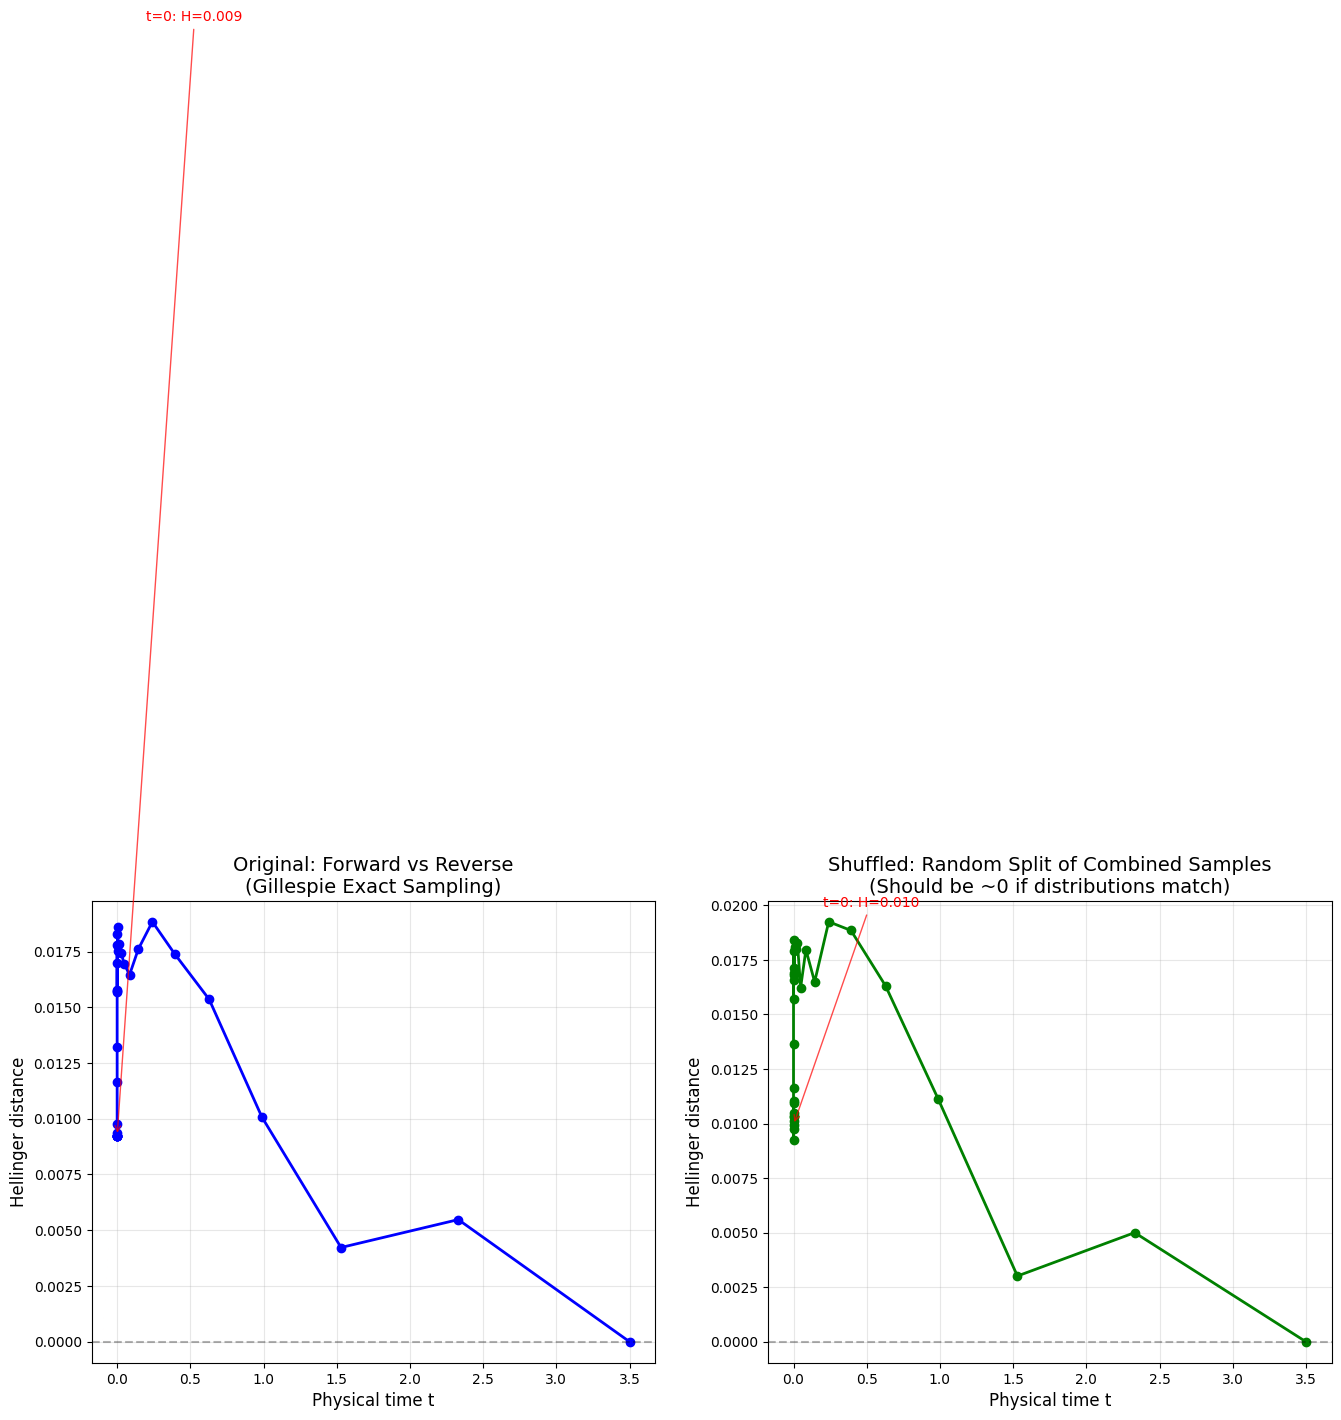

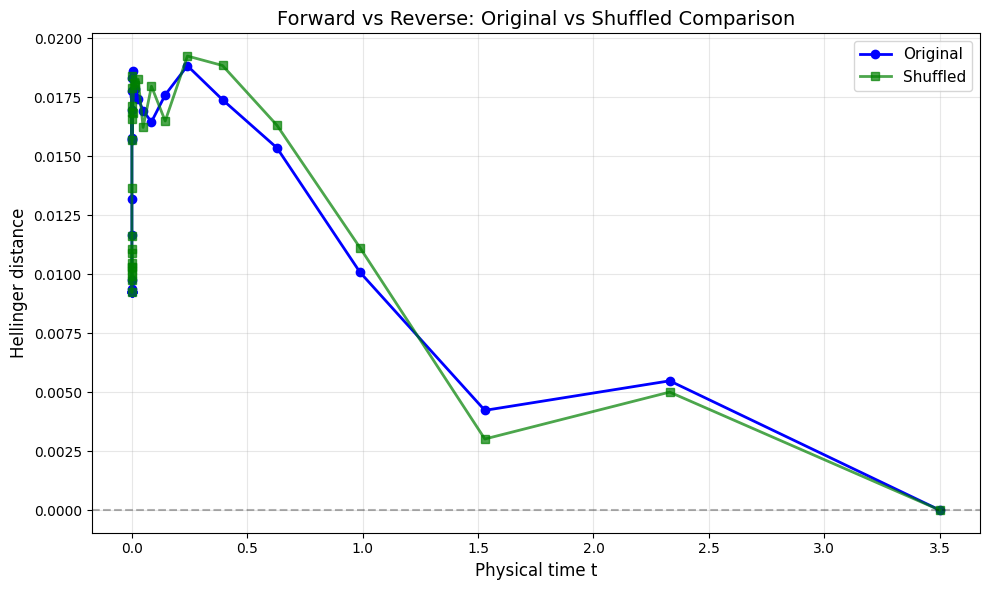


SUMMARY

Original (paired samples):
  Mean Hellinger:   0.0130
  Median Hellinger: 0.0154
  Max Hellinger:    0.0188

Shuffled (random split):
  Mean Hellinger:   0.0134
  Median Hellinger: 0.0157
  Max Hellinger:    0.0192

Experiment complete!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from main_code import DiffusionSamples, gillespie_reverse_masked, generate_forward_samples_at_checkpoints

def run_diffusion_experiment_with_gillespie(w, mu, beta, T, n_mc, checkpoint_times):
    """
    Run complete forward + reverse experiment using marginal sampling.
    """
    N = mu.shape[1]
    checkpoint_times = np.sort(np.unique(checkpoint_times))
    samples = DiffusionSamples(checkpoint_times, n_mc, N)
    method_name = "gillespie"
    samples.reverse_methods[method_name] = {}
    
    for t in checkpoint_times:
        samples.reverse_methods[method_name][float(t)] = np.empty((n_mc, N), dtype=np.int16)
    
    # 1) Forward simulation using marginals
    print("Running forward process...")
    samples.forward = generate_forward_samples_at_checkpoints(
        w, mu, beta, checkpoint_times, n_mc
    )
    
    # DEBUGGING: Check forward samples
    print("\n=== FORWARD SAMPLES DEBUG ===")
    t0 = checkpoint_times[0]
    tT = checkpoint_times[-1]
    print(f"At t={t0}:")
    print(f"  Fraction masked: {(samples.forward[float(t0)] == -1).sum() / samples.forward[float(t0)].size:.1%}")
    print(f"\nAt t={tT}:")
    print(f"  Fraction masked: {(samples.forward[float(tT)] == -1).sum() / samples.forward[float(tT)].size:.1%}")
    
    # 2) Reverse simulation   
    print("\nRunning reverse process...")
    rng = np.random.default_rng()
    
    for m in range(n_mc):
        if m % 10000 == 0:
            print(f"  Reverse particle {m}/{n_mc}")
        
        _, times, ckpt_samples = gillespie_reverse_masked(
            N, w, mu, beta, T,
            checkpoint_times=checkpoint_times,
            rng=np.random.default_rng(rng.integers(1_000_000_000))
        )
        
        # Store samples at each checkpoint
        for k, t in enumerate(times):
            samples.reverse_methods["gillespie"][float(t)][m] = ckpt_samples[k]
    
    # DEBUGGING: Check reverse samples
    print("\n=== REVERSE SAMPLES DEBUG ===")
    print(f"At t={t0}:")
    print(f"  Fraction masked: {(samples.reverse_methods['gillespie'][float(t0)] == -1).sum() / samples.reverse_methods['gillespie'][float(t0)].size:.1%}")
    print(f"\nAt t={tT}:")
    print(f"  Fraction masked: {(samples.reverse_methods['gillespie'][float(tT)] == -1).sum() / samples.reverse_methods['gillespie'][float(tT)].size:.1%}")
    
    return samples


def shuffle_and_recompute_distances(samples, method_name='gillespie', seed=42):
    """
    Shuffle forward and reverse samples at each checkpoint and recompute Hellinger.
    
    At each checkpoint:
    1. Combine forward and reverse particles
    2. Randomly split them into two groups
    3. Assign one as "forward" and one as "reverse"
    4. Compute Hellinger distance
    
    This tests if the two distributions are actually the same by breaking the pairing.
    """
    print("\n" + "=" * 70)
    print("SHUFFLING SAMPLES AND RECOMPUTING DISTANCES")
    print("=" * 70)
    
    rng = np.random.default_rng(seed)
    N = samples.metadata['N']
    n_mc = samples.metadata['n_mc']
    
    # Create new samples object for shuffled data
    shuffled_samples = DiffusionSamples(samples.times, n_mc, N)
    shuffled_samples.reverse_methods['shuffled'] = {}
    
    print("\nShuffling at each checkpoint...")
    for t in samples.times:
        # Get forward and reverse samples at this checkpoint
        forward_particles = samples.forward[float(t)]  # (n_mc, N)
        reverse_particles = samples.reverse_methods[method_name][float(t)]  # (n_mc, N)
        
        # Combine all particles
        all_particles = np.vstack([forward_particles, reverse_particles])  # (2*n_mc, N)
        
        # Shuffle
        shuffled_indices = rng.permutation(2 * n_mc)
        all_particles_shuffled = all_particles[shuffled_indices]
        
        # Split randomly into two groups
        shuffled_samples.forward[float(t)] = all_particles_shuffled[:n_mc]
        shuffled_samples.reverse_methods['shuffled'][float(t)] = all_particles_shuffled[n_mc:]
    
    print("Computing Hellinger distances on shuffled data...")
    shuffled_distances = shuffled_samples.compute_hellinger_distances('shuffled')
    
    return shuffled_samples, shuffled_distances


if __name__ == "__main__":
    print("=" * 70)
    print("Gillespie Diffusion Experiment: Forward vs Reverse Comparison")
    print("=" * 70)
    
    # Setup parameters
    N = 4      # Number of dimensions
    L = 3      # Vocabulary size per dimension
    r = 10     # Number of mixture components
    w = np.ones(r) / r
    mu = np.random.dirichlet([1]*L, size=(r, N))  # Shape: (r, N, L)
    
    beta = 5.0  # Masking rate
    T = 3.5    # Terminal time
    n_mc = 200_000  # Number of Monte Carlo samples
    
    # Checkpoint times (physical time from 0 to T)
    u = np.linspace(0, 1, 31)
    checkpoint_times = T * (u ** 12)  # More checkpoints near t=0
    
    print(f"\nParameters:")
    print(f"  N (dimensions) = {N}")
    print(f"  L (vocab size) = {L}")
    print(f"  r (components) = {r}")
    print(f"  beta (rate)    = {beta}")
    print(f"  T (term time)  = {T}")
    print(f"  n_mc (samples) = {n_mc}")
    print(f"  checkpoints    = {len(checkpoint_times)}")
    
    # Run experiment
    print("\n" + "=" * 70)
    samples = run_diffusion_experiment_with_gillespie(w, mu, beta, T, n_mc, checkpoint_times)
    
    # Compute original Hellinger distances
    print("\nComputing original Hellinger distances...")
    original_distances = samples.compute_hellinger_distances('gillespie')
    
    # Display results
    print("\nOriginal Hellinger distances at checkpoints:")
    for t in samples.times[::4]:  # Print every 4th checkpoint
        if t in original_distances:
            print(f"  t = {t:.3f}: H = {original_distances[t]:.4f}")
    
    # Final distance
    t_final = samples.times[0]  # t=0 (should be best match)
    print(f"\n*** Original Hellinger distance at t={t_final}: {original_distances[t_final]:.4f} ***")
    
    # ===== SHUFFLE AND RECOMPUTE =====
    shuffled_samples, shuffled_distances = shuffle_and_recompute_distances(samples)
    
    # Display shuffled results
    print("\nShuffled Hellinger distances at checkpoints:")
    for t in samples.times[::4]:
        if t in shuffled_distances:
            print(f"  t = {t:.3f}: H = {shuffled_distances[t]:.4f}")
    
    print(f"\n*** Shuffled Hellinger distance at t={t_final}: {shuffled_distances[t_final]:.4f} ***")
    
    # ===== PLOT BOTH: ORIGINAL AND SHUFFLED =====
    print("\nGenerating comparison plot...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Original
    ax1.plot(samples.times, [original_distances[t] for t in samples.times], 
             'o-', linewidth=2, markersize=6, label='Original', color='blue')
    ax1.set_xlabel('Physical time t', fontsize=12)
    ax1.set_ylabel('Hellinger distance', fontsize=12)
    ax1.set_title('Original: Forward vs Reverse\n(Gillespie Exact Sampling)', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Annotate
    t0 = samples.times[0]
    tT = samples.times[-1]
    ax1.annotate(f't=0: H={original_distances[t0]:.3f}', 
                xy=(t0, original_distances[t0]), 
                xytext=(0.2, original_distances[t0] + 0.05),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                fontsize=10, color='red')
    
    # Plot 2: Shuffled
    ax2.plot(samples.times, [shuffled_distances[t] for t in samples.times], 
             'o-', linewidth=2, markersize=6, label='Shuffled', color='green')
    ax2.set_xlabel('Physical time t', fontsize=12)
    ax2.set_ylabel('Hellinger distance', fontsize=12)
    ax2.set_title('Shuffled: Random Split of Combined Samples\n(Should be ~0 if distributions match)', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Annotate
    ax2.annotate(f't=0: H={shuffled_distances[t0]:.3f}', 
                xy=(t0, shuffled_distances[t0]), 
                xytext=(0.2, shuffled_distances[t0] + 0.01),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                fontsize=10, color='red')
    
    plt.tight_layout()
    plt.savefig('gillespie_original_vs_shuffled.png', dpi=150, bbox_inches='tight')
    print("Plot saved to: gillespie_original_vs_shuffled.png")
    
    # ===== OVERLAY PLOT =====
    print("Generating overlay plot...")
    plt.figure(figsize=(10, 6))
    plt.plot(samples.times, [original_distances[t] for t in samples.times], 
             'o-', linewidth=2, markersize=6, label='Original', color='blue')
    plt.plot(samples.times, [shuffled_distances[t] for t in samples.times], 
             's-', linewidth=2, markersize=6, label='Shuffled', color='green', alpha=0.7)
    plt.xlabel('Physical time t', fontsize=12)
    plt.ylabel('Hellinger distance', fontsize=12)
    plt.title('Forward vs Reverse: Original vs Shuffled Comparison', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('gillespie_overlay_comparison.png', dpi=150, bbox_inches='tight')
    print("Plot saved to: gillespie_overlay_comparison.png")
    
    plt.show()
    
    # ===== SUMMARY =====
    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print(f"\nOriginal (paired samples):")
    print(f"  Mean Hellinger:   {np.mean(list(original_distances.values())):.4f}")
    print(f"  Median Hellinger: {np.median(list(original_distances.values())):.4f}")
    print(f"  Max Hellinger:    {np.max(list(original_distances.values())):.4f}")
    
    print(f"\nShuffled (random split):")
    print(f"  Mean Hellinger:   {np.mean(list(shuffled_distances.values())):.4f}")
    print(f"  Median Hellinger: {np.median(list(shuffled_distances.values())):.4f}")
    print(f"  Max Hellinger:    {np.max(list(shuffled_distances.values())):.4f}")
    
    print("\n" + "=" * 70)
    print("Experiment complete!")
    print("=" * 70)